## Ames Housing Price Analysis
Exploring what drives house prices in the Ames, Iowa housing dataset (2,930 homes, 81 features). Filtered to 9 core variables covering quality, size, age, and location.

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
df = pd.read_csv('AmesHousing.csv')
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [147]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.columns.to_list()

['order',
 'pid',
 'ms_subclass',
 'ms_zoning',
 'lot_frontage',
 'lot_area',
 'street',
 'alley',
 'lot_shape',
 'land_contour',
 'utilities',
 'lot_config',
 'land_slope',
 'neighborhood',
 'condition_1',
 'condition_2',
 'bldg_type',
 'house_style',
 'overall_qual',
 'overall_cond',
 'year_built',
 'year_remod/add',
 'roof_style',
 'roof_matl',
 'exterior_1st',
 'exterior_2nd',
 'mas_vnr_type',
 'mas_vnr_area',
 'exter_qual',
 'exter_cond',
 'foundation',
 'bsmt_qual',
 'bsmt_cond',
 'bsmt_exposure',
 'bsmtfin_type_1',
 'bsmtfin_sf_1',
 'bsmtfin_type_2',
 'bsmtfin_sf_2',
 'bsmt_unf_sf',
 'total_bsmt_sf',
 'heating',
 'heating_qc',
 'central_air',
 'electrical',
 '1st_flr_sf',
 '2nd_flr_sf',
 'low_qual_fin_sf',
 'gr_liv_area',
 'bsmt_full_bath',
 'bsmt_half_bath',
 'full_bath',
 'half_bath',
 'bedroom_abvgr',
 'kitchen_abvgr',
 'kitchen_qual',
 'totrms_abvgrd',
 'functional',
 'fireplaces',
 'fireplace_qu',
 'garage_type',
 'garage_yr_blt',
 'garage_finish',
 'garage_cars',
 'garage_

### Data Preparation
Selecting the 9 features most relevant to price and handling missing values before analysis.

In [148]:
col_needed = [
    'neighborhood',
    'overall_qual',
    'overall_cond',
    'year_built',
    'year_remod/add',
    'gr_liv_area',
    'total_bsmt_sf',
    'garage_cars',  
    'saleprice'
]
df_9=df[col_needed].copy()

#clean the data

In [149]:
df_9['total_bsmt_sf']=df_9['total_bsmt_sf'].fillna(df_9['total_bsmt_sf'].median())
print(df_9['total_bsmt_sf'].isnull().sum())

0


In [150]:
df_9['garage_cars']=df_9['garage_cars'].fillna(df_9['garage_cars'].median())

In [151]:
df_9.isnull().sum()

neighborhood      0
overall_qual      0
overall_cond      0
year_built        0
year_remod/add    0
gr_liv_area       0
total_bsmt_sf     0
garage_cars       0
saleprice         0
dtype: int64

In [152]:
print(df_9.corr(numeric_only=True)['saleprice'])

overall_qual      0.799262
overall_cond     -0.101697
year_built        0.558426
year_remod/add    0.532974
gr_liv_area       0.706780
total_bsmt_sf     0.632164
garage_cars       0.647812
saleprice         1.000000
Name: saleprice, dtype: float64


## Q1: How do the 9 features correlate with each other and with sale price?

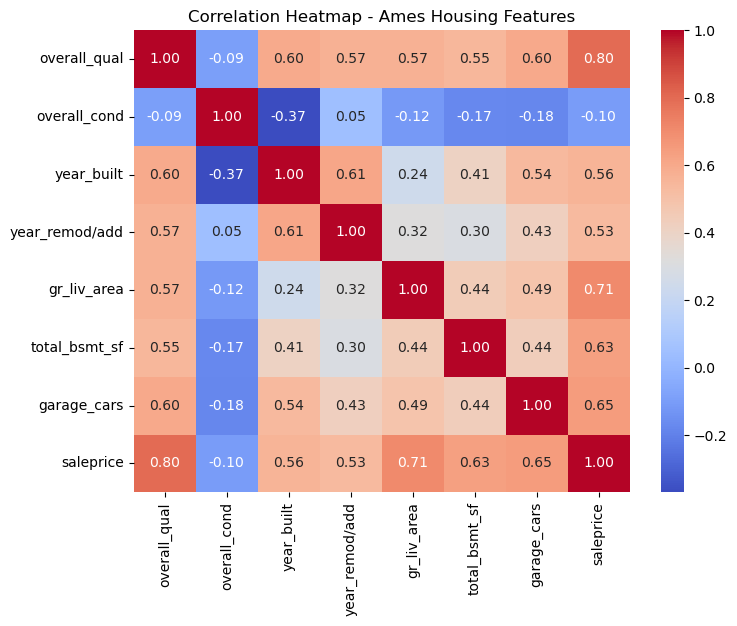

In [153]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_9.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Ames Housing Features')
plt.savefig('correlation.png', dpi=300, bbox_inches='tight')

plt.show()

## Q2: What is the average, minimum, and maximum sale price?

In [154]:
average = df_9['saleprice'].mean()
maximum = df_9['saleprice'].max()
minimum = df_9['saleprice'].min()

print('----result----')
print(f'the average sale price is: ${average:,.2f}')
print(f'the maximum sale price is: ${maximum:,.2f}')
print(f'the minimum sale price is: ${minimum:,.2f}')

----result----
the average sale price is: $180,796.06
the maximum sale price is: $755,000.00
the minimum sale price is: $12,789.00


## Q3: What is the price spread, and which houses are statistical outliers (±2 SD)?

In [155]:


std = df_9['saleprice'].std()
mean =df_9['saleprice'].mean()
lower =mean - (2*std)
upper = mean +(2*std)


outlier =df_9[(df_9['saleprice']<lower) | (df_9['saleprice']>upper)]
        
total = len(outlier)


print('----result-----')
print(f'the std is:{std}')
print(f'lower limit:{lower:,.2f}')
print(f'upper limit:{upper:,.2f}')
print(f'the total numbers  outlier are:{total}')






----result-----
the std is:79886.692356665
lower limit:21,022.68
upper limit:340,569.44
the total numbers  outlier are:136


# Q4: Where do most house prices actually cluster?

In [156]:

price_distribution = pd.cut(df_9['saleprice'],bins=[0, 100000, 160000, 250000, 350000, 500000, float('inf')],
                            labels=['Budget', 'Mid-Low', 'Average', 'Mid-High', 'High-End', 'Luxury'])
price_distribution.value_counts()


saleprice
Mid-Low     1215
Average     1018
Mid-High     326
Budget       252
High-End     102
Luxury        17
Name: count, dtype: int64

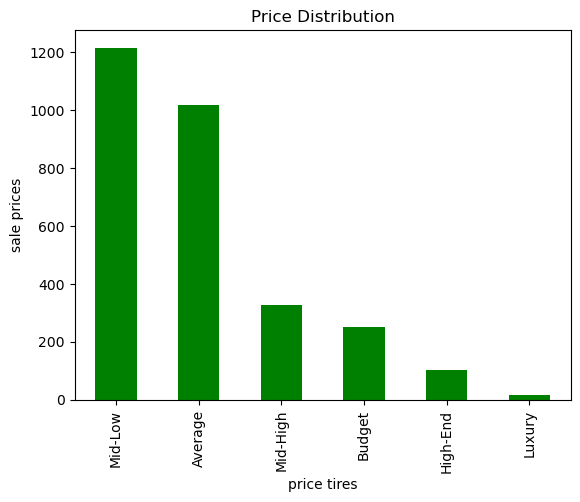

In [157]:
price_distribution.value_counts().plot(kind='bar',color='green')
plt.title('Price Distribution')
plt.xlabel('price tires')
plt.ylabel('sale prices')
plt.savefig('price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()




# Q5: Which single feature has the strongest correlation with sale price?

In [158]:

col = df_9.corr(numeric_only=True)['saleprice'].sort_values(ascending=False)
col

saleprice         1.000000
overall_qual      0.799262
gr_liv_area       0.706780
garage_cars       0.647812
total_bsmt_sf     0.632164
year_built        0.558426
year_remod/add    0.532974
overall_cond     -0.101697
Name: saleprice, dtype: float64

## Q6: How does average price change across quality levels (1–10)?

In [159]:

all_average = df_9.groupby('overall_qual')['saleprice'].mean()

print(all_average.map('${:,.2f}'.format))
print("\n" + "="*40 + "\n")

quality_9 = all_average.loc[9]
quality_5 = all_average.loc[5]

difference_price = quality_9 - quality_5

print('-------------')
print(f'the average cost of quality9 is:{quality_9:,.2f}')
print(f'the average cost of quality5 is:{quality_5:,.2f}')

print(f'the difference quality_9 and quality_5 is:{difference_price:,.2f}')





overall_qual
1      $48,725.00
2      $52,325.31
3      $83,185.98
4     $106,485.10
5     $134,752.52
6     $162,130.32
7     $205,025.76
8     $270,913.59
9     $368,336.77
10    $450,217.32
Name: saleprice, dtype: str


-------------
the average cost of quality9 is:368,336.77
the average cost of quality5 is:134,752.52
the difference quality_9 and quality_5 is:233,584.25


## Q7: Does living area (size) correlate with price — do bigger houses always sell for more?

In [160]:


correlation = df_9['gr_liv_area'].corr(df_9['saleprice'])
print('--------------')
print(f'The correlation between size and price:{correlation}')


print('-------')
df_9['size_bin']=pd.qcut(df_9['gr_liv_area'],q=4,labels=['Small', 'Medium', 'Large', 'XL'])



# 1. Group by size bins and calculate min, median, and max prices dynamically
size_ranges = df_9.groupby('size_bin')['saleprice'].agg(['min', 'median', 'max'])

print("--- The Real Range of House Prices by Size ---")

print(size_ranges.map('${:,.0f}'.format))




--------------
The correlation between size and price:0.706779920976627
-------
--- The Real Range of House Prices by Size ---
              min    median       max
size_bin                             
Small     $12,789  $124,000  $200,000
Medium    $40,000  $153,500  $392,000
Large     $50,000  $183,000  $392,500
XL        $62,500  $239,900  $755,000


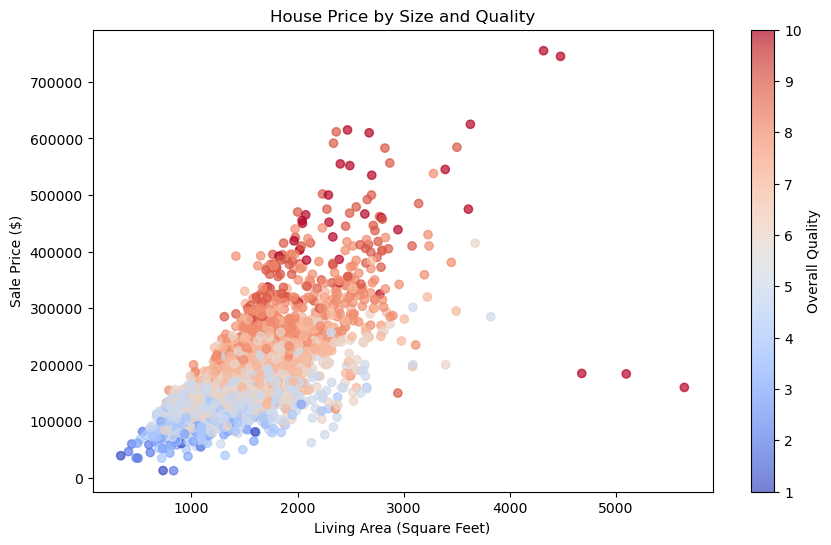

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_9['gr_liv_area'],
    df_9['saleprice'],
    c=df_9['overall_qual'],
    cmap='coolwarm',
    alpha=0.7
)

plt.title('House Price by Size and Quality')
plt.xlabel('Living Area (Square Feet)')
plt.ylabel('Sale Price ($)')

# Colorbar showing what each color represents
cbar = plt.colorbar(scatter)
cbar.set_label('Overall Quality')

plt.savefig(
    'House Price by Size and Quality.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Q8: Which quality + size combination gives the highest average price?

In [162]:


combination = df_9.groupby(['overall_qual','size_bin'])['saleprice'].mean()
sorted_combination = combination.sort_values(ascending=False)
print(sorted_combination.head(10))

overall_qual  size_bin
10            XL          453974.566667
9             XL          391148.810127
10            Large       337500.000000
9             Large       305241.461538
8             XL          298929.945355
9             Medium      287500.000000
8             Large       255473.586207
7             XL          231928.523364
8             Medium      208318.304348
7             Large       201971.584541
Name: saleprice, dtype: float64


#Quality 10 + XL size shows the highest reliable average price ($453,974, n=30) — a real, trustworthy pattern despite being a rarer combination. Quality 10 + Large (n=1) is excluded from this conclusion since it reflects a single house, not a trend

## Q9: Which neighborhoods are the highest- and lowest-priced?

In [163]:


neighborhood_average = df_9.groupby('neighborhood')['saleprice'].mean()
sorted_average=neighborhood_average.sort_values(ascending=False)

print("\n--- The highest Priced Neighborhoods" )
print(sorted_average.head(3))

print("\n--- The Lowest Priced Neighborhoods" )
print(sorted_average.tail(3))


--- The highest Priced Neighborhoods
neighborhood
NoRidge    330319.126761
StoneBr    324229.196078
NridgHt    322018.265060
Name: saleprice, dtype: float64

--- The Lowest Priced Neighborhoods
neighborhood
BrDale     105608.333333
IDOTRR     103752.903226
MeadowV     95756.486486
Name: saleprice, dtype: float64


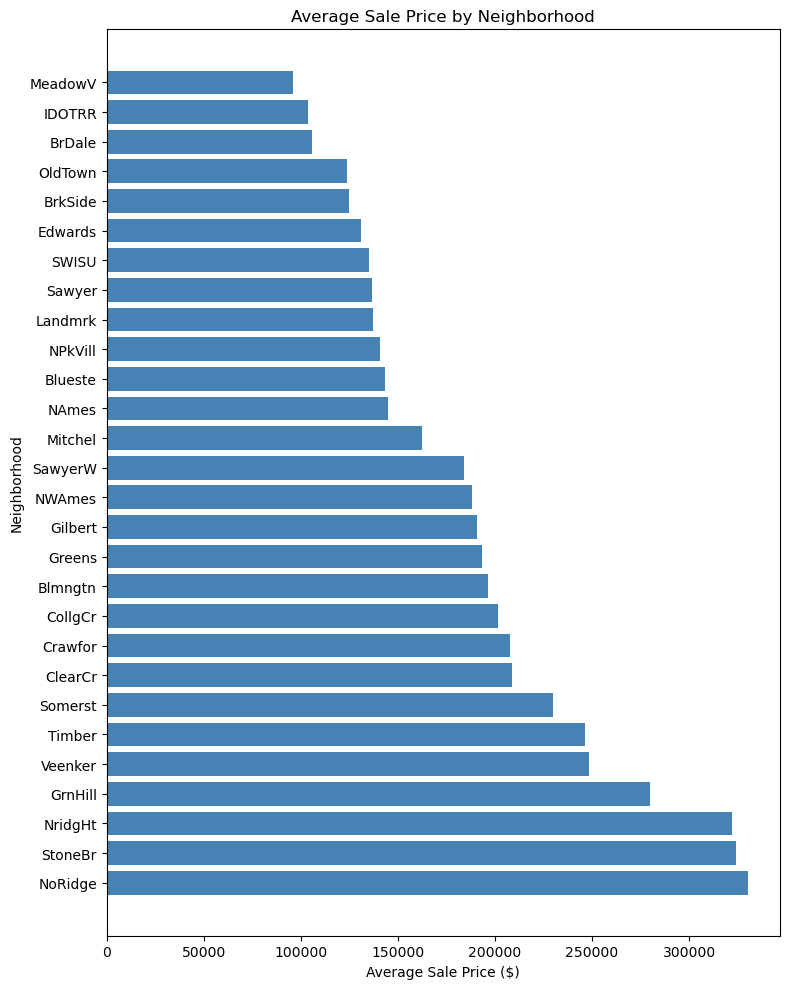

In [164]:


plt.figure(figsize=(8, 10))
plt.barh(sorted_average.index, sorted_average.values, color='steelblue')
plt.title('Average Sale Price by Neighborhood')
plt.xlabel('Average Sale Price ($)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.savefig('average saleprice by neighborhood.png', dpi=300, bbox_inches='tight')
plt.show()


## Q10: Does the same quality level sell for different prices in different neighborhoods?

In [165]:

quality_7_houses     =     df_9[df_9['overall_qual']==7]
neighborhood_quality =     quality_7_houses.groupby('neighborhood')['saleprice'].mean().sort_values(ascending=False)


print(neighborhood_quality )


neighborhood
GrnHill    280000.000000
Veenker    270120.000000
NoRidge    265525.882353
ClearCr    245557.142857
StoneBr    235500.000000
Timber     229304.611111
Crawfor    220118.653846
SawyerW    213618.836735
NridgHt    212917.400000
Mitchel    211370.428571
CollgCr    209056.655738
Somerst    206166.733333
Gilbert    196857.041096
NWAmes     196857.000000
Sawyer     192125.000000
NAmes      192054.166667
Blmngtn    192019.416667
Edwards    175453.000000
IDOTRR     173733.333333
BrkSide    165142.857143
SWISU      163666.666667
OldTown    157780.703704
NPkVill    133333.333333
Name: saleprice, dtype: float64


## Q11: Do newer houses sell for more, and does this hold across neighborhoods?

In [166]:

year_avg = df_9['year_built'].corr(df_9['saleprice'])
year_avg

#we do specify two neighborhood, one is old and another is newer

#the old ones
old_neighborhood=df_9[df_9['neighborhood']=='OldTown']
old_town_corr =old_neighborhood['year_built'].corr(old_neighborhood['saleprice'])


#he newer 
modern_neighborhood=df_9[df_9['neighborhood']=='NridgHt']
modern_neighborhood_corr =modern_neighborhood['year_built'].corr(modern_neighborhood['saleprice'])

print("--- Testing the Age Rule Across Different Neighborhoods ---")
print(f'the correlation between year_built and  neighborhoods{year_avg:,.2f}')
print(f"Age-to-Price Correlation inside OldTown: {old_town_corr:.2f}")
print(f"Age-to-Price Correlation inside NridgHt: {modern_neighborhood_corr:.2f}")



--- Testing the Age Rule Across Different Neighborhoods ---
the correlation between year_built and  neighborhoods0.56
Age-to-Price Correlation inside OldTown: -0.17
Age-to-Price Correlation inside NridgHt: 0.22


##  Q12: Ranking all factors — which matters most: quality, size, location, or age? What single improvement would raise a house's sale pricethe most?

In [167]:


factor = df_9[['saleprice', 'overall_qual', 'gr_liv_area', 'year_built']]
factor_rankings = factor.corr()['saleprice']
# 3. Print the results sorted from highest to lowest score
print("--- Final Factor Ranking Against Sale Price ---")
print(factor_rankings.sort_values(ascending=False))

--- Final Factor Ranking Against Sale Price ---
saleprice       1.000000
overall_qual    0.799262
gr_liv_area     0.706780
year_built      0.558426
Name: saleprice, dtype: float64


Location can't be measured with a correlation coefficient since it's categorical, not numeric. But Cell 21 shows the gap between the highest and lowest-priced neighborhoods is about $235k — larger than what any single point of quality or year_built shift produces. This suggests location is not just "a factor" but potentially the strongest one, even though it can't appear in the numeric ranking above.




In [168]:
df_9.to_csv('cleaned_data.csv',index=False)
print('saved',df_9.shape)

saved (2930, 10)
